### SECTION 1 — Setup

In [2]:
# Imports and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = pd.read_csv("../data/nhs_waiting_times.csv")

# check data structure
# print(df.shape)
# print(df.columns[:20])

## Section 2 - Exploration of the dataset 

### 2.1 Dataset Overview

The dataset contains NHS Referral to Treatment (RTT) waiting time information, broken down by provider organisation, commissioning organisation, treatment specialty, and waiting-time bands.
The data is stored in a wide format, where each row represents waiting list counts for a provider, treatment type, and time period, broken down by waiting time bands.

The data frame consists of 121 columns including 105 bucket columns representing called "Gt A To B Weeks SUM 1" representing the number of patients whose waiting time for a consultant-led elective treatment is Greater than A weeks but B weeks or less. The remaining 16 columns include information on time period, provider, commissioner, and treatment function. 

In [3]:
df["Period"].unique()

array(['RTT-February-2026'], dtype=object)

The period column only contains RTT-February-2026, so it doesn't provide any useful information for analysis. We can drop it from the dataset.

### 2.2 Identify variable groups
The variables can broadly be divided into:
- Identifier variables (provider, commissioner, treatment function)
- Reporting variables (totals and unknown clock starts)
- Waiting-time distribution variables (weekly waiting buckets)

Some columns are repeats (for example, `Treatment function code` is equivalent to `Treatment function name`).

Each row represents waiting-time counts for a specific provider, commissioner, treatment specialty and RTT pathway category with patients distributed across weekly waiting-time bands.

In [4]:
identifier_cols = [
    "Provider Parent Name",
    "Provider Org Name",
    "Commissioner Parent Name",
    "Commissioner Org Name",
    "Treatment Function Name",
    "RTT Part Description"
]

reporting_cols = [
    "Total",
    "Total All",
    "Patients with unknown clock start date"
]

wait_cols = [c for c in df.columns if "Weeks SUM 1" in c]

print("Identifier columns:", len(identifier_cols))
print("Reporting columns:", len(reporting_cols))
print("Waiting bucket columns:", len(wait_cols))

# Analyse an individual row
df.iloc[0]

Identifier columns: 6
Reporting columns: 3
Waiting bucket columns: 105


Period                                                                    RTT-February-2026
Provider Parent Org Code                                                                QE1
Provider Parent Name                      NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...
Provider Org Code                                                                     A4M8P
Provider Org Name                                                         BUCKSHAW HOSPITAL
                                                                ...                        
Gt 103 To 104 Weeks SUM 1                                                               0.0
Gt 104 Weeks SUM 1                                                                      0.0
Total                                                                                   NaN
Patients with unknown clock start date                                                  NaN
Total All                                                                       

### 2.3 PROVIDER VS COMMISSIONER
The provider is the organisation delivering care, e.g. Leeds Teaching Hospitals NHS Trust. The commissioner is the organisation funding/commissioning care. We can identify the top providers and commissioners:

In [5]:
df["Provider Org Name"].value_counts().head()
df["Commissioner Org Name"].value_counts().head()

Commissioner Org Name
NHS NORTH WEST LONDON (SUB ICB LOCATION)    4055
NHS NORTH EAST LONDON (SUB ICB LOCATION)    3206
NHS SOUTH WEST LONDON (SUB ICB LOCATION)    3147
NHS KENT AND MEDWAY (SUB ICB LOCATION)      3090
NHS SURREY HEARTLANDS (SUB ICB LOCATION)    3065
Name: count, dtype: int64

## Section 3 - Data Quality Assessment

### 3.1 Missing Value Assessment

Before conducting analysis, the dataset was assessed for potential data quality issues, including missing values and incomplete RTT clock start information.

In [6]:
df.isna().sum().sort_values(ascending=False).head(20)

Patients with unknown clock start date    148166
Total                                     131075
Gt 91 To 92 Weeks SUM 1                    56788
Gt 103 To 104 Weeks SUM 1                  56786
Gt 87 To 88 Weeks SUM 1                    56786
Gt 102 To 103 Weeks SUM 1                  56786
Gt 99 To 100 Weeks SUM 1                   56786
Gt 95 To 96 Weeks SUM 1                    56785
Gt 97 To 98 Weeks SUM 1                    56784
Gt 101 To 102 Weeks SUM 1                  56784
Gt 100 To 101 Weeks SUM 1                  56784
Gt 92 To 93 Weeks SUM 1                    56784
Gt 90 To 91 Weeks SUM 1                    56783
Gt 94 To 95 Weeks SUM 1                    56783
Gt 85 To 86 Weeks SUM 1                    56782
Gt 98 To 99 Weeks SUM 1                    56782
Gt 86 To 87 Weeks SUM 1                    56782
Gt 96 To 97 Weeks SUM 1                    56781
Gt 88 To 89 Weeks SUM 1                    56781
Gt 82 To 83 Weeks SUM 1                    56780
dtype: int64

Several columns contain missing values, requiring cleaning and careful interpretation. We can check reconstructed totals against existing non-missing totals to confirm consistency between the reported totals and bucket-level counts.

In [18]:
# Fill in missing total values by summing the waiting bucket columns
# Sum over rows where any of the waiting bucket columns are NaN
df['total_sum'] = df.iloc[:, 13:118].sum(axis=1, skipna=False)
same_totals = df[df['total_sum'] == df['Total']]

same_totals.head(10) # 42900 entries


,Period,Provider Parent Org Code,Provider Parent Name,Provider Org Code,Provider Org Name,Commissioner Parent Org Code,Commissioner Parent Name,Commissioner Org Code,Commissioner Org Name,RTT Part Type,...,Gt 99 To 100 Weeks SUM 1,Gt 100 To 101 Weeks SUM 1,Gt 101 To 102 Weeks SUM 1,Gt 102 To 103 Weeks SUM 1,Gt 103 To 104 Weeks SUM 1,Gt 104 Weeks SUM 1,Total,Patients with unknown clock start date,Total All,total_sum
7,RTT-February-2026,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,00Q,NHS BLACKBURN WITH DARWEN (SUB ICB LOCATION),Part_1A,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1.0
8,RTT-February-2026,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,00Q,NHS BLACKBURN WITH DARWEN (SUB ICB LOCATION),Part_1A,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1.0
9,RTT-February-2026,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,00Q,NHS BLACKBURN WITH DARWEN (SUB ICB LOCATION),Part_1B,...,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,7,7.0
10,RTT-February-2026,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,00Q,NHS BLACKBURN WITH DARWEN (SUB ICB LOCATION),Part_1B,...,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,4,4.0
11,RTT-February-2026,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,00Q,NHS BLACKBURN WITH DARWEN (SUB ICB LOCATION),Part_1B,...,0.0,0.0,0.0,0.0,0.0,0.0,11.0,0.0,11,11.0
29,RTT-February-2026,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,00R,NHS BLACKPOOL (SUB ICB LOCATION),Part_1B,...,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,7,7.0
30,RTT-February-2026,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,00R,NHS BLACKPOOL (SUB ICB LOCATION),Part_1B,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2,2.0
31,RTT-February-2026,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,00R,NHS BLACKPOOL (SUB ICB LOCATION),Part_1B,...,0.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,9,9.0
45,RTT-February-2026,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,00X,NHS CHORLEY AND SOUTH RIBBLE (SUB ICB LOCATION),Part_1A,...,0.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,9,9.0
46,RTT-February-2026,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,A4M8P,BUCKSHAW HOSPITAL,QE1,NHS LANCASHIRE AND SOUTH CUMBRIA INTEGRATED CA...,00X,NHS CHORLEY AND SOUTH RIBBLE (SUB ICB LOCATION),Part_1A,...,0.0,0.0,0.0,0.0,0.0,0.0,20.0,0.0,20,20.0


We find that the `total_sum` can be different to the `Total` because there are occassionally entries in `Total` despite missing values in the waiting buckets. In this situation, we leave the `Total` value as is.

Now we have checked consistency, we can fill the missing columns (where possible). We can sum over the buckets of waiting times (ignoring any rows that contain NaN values in these buckets) to find the total number of patients with known clock starts, and then use this to fill any missing values.

In [ ]:
mismatches = df[df['total_sum'] != df['Total']]
mismatches['Total'].unique() # Shows that the 'Total' column is missing for these rows, so we can fill it with the sum of the waiting buckets
df['Total'] = df['Total'].fillna(df['total_sum'])
df.drop(columns=['total_sum'], inplace=True)

# Fill the `Patients with unknown clock start date` column using the `Total All` and `Total` columns
df['diff'] = df['Total All'] - df['Total']
df['Patients with unknown clock start date'] = df['Patients with unknown clock start date'].fillna(df['diff'])
df.drop(columns=['diff'], inplace=True)

In [55]:
# Example DataFrame
df2 = pd.DataFrame({'Score1': [62, 47, 55], 'Score2': [45, 78, 44]})

# Calculate difference and create a new column
df2['Diff'] = df2['Score1'] - df2['Score2']

We can then use this updated `Total` column to fill the `Patients with unknown clock start date` column where applicable.

### 3.2 Understand unknown clock starts
The column "Total Patients with unknown clock start date" represents the number of patients on an RTT pathway (waiting for treatment) where the trust cannot identify the precise date the RTT clock started, often due to administrative issues or delays in receiving referral information. This usually indicates a data quality issue or a failed Inter Provider Transfer (IPT). Hence, I will create a data quality metric quantifying this situation. 

In [63]:
df["Patients with unknown clock start date"].count()
df["unknown_rate"] = (
    df["Patients with unknown clock start date"] /
    df["Total All"]
)

We can use this metric to find which providers may have poorer reporting quality, operational variation or possible system issues

In [62]:
provider_quality = (
    df.groupby("Provider Org Name")["unknown_rate"]
    .mean()
    .sort_values(ascending=False)
)

provider_quality.head(10)

Provider Org Name
WIRRAL UNIVERSITY TEACHING HOSPITAL NHS FOUNDATION TRUST          0.031505
GREAT ORMOND STREET HOSPITAL FOR CHILDREN NHS FOUNDATION TRUST    0.029589
UNIVERSITY HOSPITALS PLYMOUTH NHS TRUST                           0.006179
UNITED LINCOLNSHIRE TEACHING HOSPITALS NHS TRUST                  0.003842
ROYAL SURREY NHS FOUNDATION TRUST                                 0.002448
OVIVA UK LTD                                                      0.000211
MID AND SOUTH ESSEX NHS FOUNDATION TRUST                          0.000142
NORTH WEST ANGLIA NHS FOUNDATION TRUST                            0.000132
ROYAL FREE LONDON NHS FOUNDATION TRUST                            0.000108
LEEDS TEACHING HOSPITALS NHS TRUST                                0.000027
Name: unknown_rate, dtype: float64

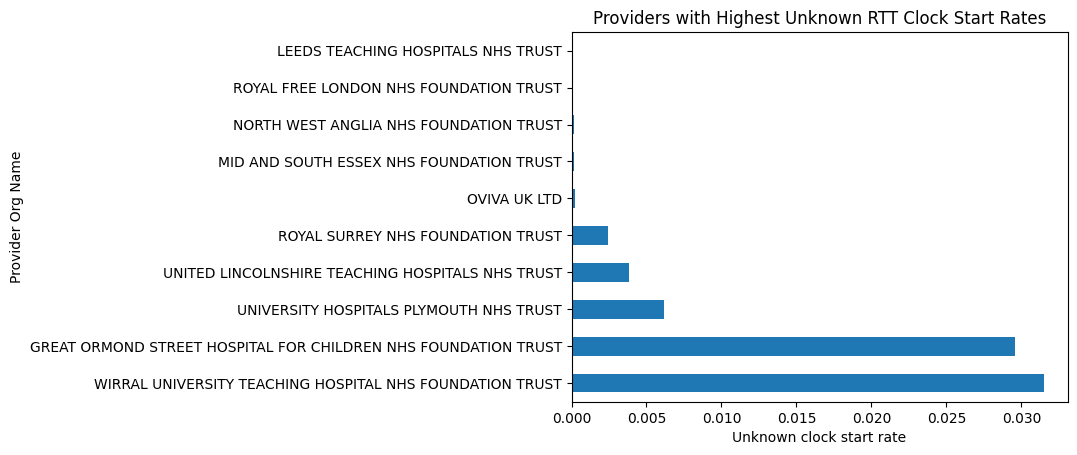

In [64]:
provider_quality.head(10).plot(kind="barh")

plt.title("Providers with Highest Unknown RTT Clock Start Rates")
plt.xlabel("Unknown clock start rate")
plt.show()

### 3.3 Check total consistency
Now verify whether bucket sums align with totals.

In [ ]:
wait_cols = [c for c in df.columns if "Weeks SUM 1" in c]
df["calculated_total"] = df[wait_cols].sum(axis=1)
(
    df["calculated_total"] -
    df["Total"]
).unique() # Shows that the calculated total matches the reported total for all rows, confirming that the waiting bucket columns sum to the total column.

array([ 0., nan])

### 3.4 Summary of findings
Rather than removing incomplete records, missing total waiting-time values were derived from the sum of the constituent waiting-time buckets. This leveraged the hierarchical structure of the dataset and reduced avoidable data loss while maintaining consistency with the reporting framework. Variation also exists in the proportion of patients with unknown RTT clock start dates across providers, suggesting differences in referral tracking and data quality processes.

## 4 Waiting-Time Distribution Engineering
The goal of this section is to find meaningful summary features, interpretable clinical metrics and analysis-ready variables from the available data.